# 03. Module A models: control limits, Isolation Forest, LSTM autoencoder

Three unsupervised detectors, all fitted **only on healthy minutes** (1 Feb – 10 Apr, minus the two unreported leak-like episodes found in notebook 02). No failure label is used for training or for choosing thresholds.

| Model | Input | Score | Default alert threshold |
|---|---|---|---|
| ±3σ control limits | 5 leak-physics features (duty cycle, max run, starts/h, idle decay, oil excess) | max \|z\| across features | 3σ (classic SPC) |
| Isolation Forest | 13 engineered features | −decision function | 99.5th pct of smoothed healthy scores |
| LSTM autoencoder | 30-min windows of 8 minute-level signals | reconstruction MSE | 99.5th pct of smoothed healthy scores |

**Alert rule** (identical for all three): trailing 30-min median of the score → above threshold → alert once it has stayed above for **60 min**, with no data gap > 5 min.

**Back-test rules** (`backtest.py`):
- An alert overlapping `[failure start − 72 h, logged maintenance]` belongs to that failure. Anything else is a false alert.
- *Flagged early* = the alert starts before the reported failure start. *Detected* = it starts before the failure ends.
- False alerts per month are counted on the out-of-sample period only (11 Apr → 1 Sep).

In [1]:
import sys
import warnings
from pathlib import Path

# Make `src/` importable whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from compressor_guard.config import FIGURES_DIR, load_params

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
params = load_params()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
FAIL_COLOR, ALERT_COLOR, FROZEN_COLOR = "#d62728", "#ff7f0e", "#7f7f7f"

import json
from compressor_guard.alerts import generate_alerts
from compressor_guard.backtest import backtest_scores, evaluate_backtest, results_row
from compressor_guard.data import load_failures
from compressor_guard.features import load_features_parquet
from compressor_guard.models import (_log_mlflow, save_detectors, score_detectors, train_detectors,
                                     training_mask)

feats = load_features_parquet(ROOT / params["metropt"]["processed_parquet_path"])
failures = load_failures(ROOT / "config/failures.yaml")
MODELS = ["control_limits", "isolation_forest", "lstm_autoencoder"]
LABELS = {"control_limits": "±3σ control limits", "isolation_forest": "Isolation Forest",
          "lstm_autoencoder": "LSTM autoencoder"}
print(f"{len(feats):,} minutes; training on {training_mask(feats, params).sum():,} healthy minutes")

242,498 minutes; training on 83,158 healthy minutes


## 1. Train (≈ 1–2 min on CPU; the LSTM dominates)

Models, thresholds and MLflow runs are saved, so the API, dashboard and streaming replay all use exactly these detectors.

[models] fitting control_limits on 83,158 healthy minutes ...
[models] fitting isolation_forest on 83,158 healthy minutes ...
[models] fitting lstm_autoencoder on 83,158 healthy minutes ...


/opt/anaconda3/envs/ml-core/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[models] logged runs to MLflow at sqlite:////Users/st_dare/Documents/git/compressor-guard/mlflow.db


,alert threshold
control_limits,3.000000
isolation_forest,0.061287
lstm_autoencoder,3.515457


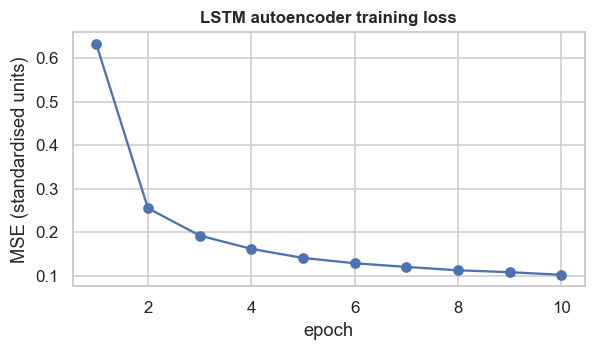

In [2]:
dets = train_detectors(feats, params, include_lstm=True)
save_detectors(dets, ROOT / params["metropt"]["model_dir"])
_log_mlflow(dets, params, int(training_mask(feats, params).sum()))

scores = score_detectors(dets, feats)
scores.to_parquet(ROOT / params["metropt"]["scores_parquet_path"], index=False)
display(pd.Series({n: d.threshold for n, d in dets.items()}, name="alert threshold").to_frame())

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, len(dets["lstm_autoencoder"].train_loss) + 1), dets["lstm_autoencoder"].train_loss, marker="o")
ax.set(title="LSTM autoencoder training loss", xlabel="epoch", ylabel="MSE (standardised units)")
plt.show()

## 2. Back-test against the four reported failures

In [3]:
results, details = {}, []
for n in MODELS:
    results[n] = backtest_scores(scores, f"score_{n}", dets[n].threshold, params, failures=failures)
    details.append(results[n]["failure_details"].assign(model=LABELS[n]))

table = pd.DataFrame([results_row(LABELS[n], results[n]) for n in MODELS])
(ROOT / "reports").mkdir(exist_ok=True)
table.to_csv(ROOT / "reports/module_a_results.csv", index=False)
display(table)

det = pd.concat(details)[["model", "failure_id", "first_alert", "flagged_early", "lead_time_hours",
                          "detected", "detection_delay_hours"]]
det.to_csv(ROOT / "reports/module_a_failure_details.csv", index=False)
display(det.round(1))

,model,flagged_early,detected_by_end,median_lead_h,false_alerts,false_alerts_per_month,net_value_usd
0,±3σ control limits,2 / 4,4 / 4,52.3,29,6.17,17500
1,Isolation Forest,1 / 4,4 / 4,35.2,8,1.70,12000
2,LSTM autoencoder,1 / 4,4 / 4,46.6,6,1.28,13000


,model,failure_id,first_alert,flagged_early,lead_time_hours,detected,detection_delay_hours
0,±3σ control limits,F1,2020-04-18 01:22:00,False,0.0,True,1.4
1,±3σ control limits,F2,2020-05-30 00:46:00,False,0.0,True,1.3
2,±3σ control limits,F3,2020-06-03 11:39:00,True,46.4,True,0.0
3,±3σ control limits,F4,2020-07-13 04:15:00,True,58.2,True,0.0
0,Isolation Forest,F1,2020-04-18 01:23:00,False,0.0,True,1.4
1,Isolation Forest,F2,2020-05-30 03:15:00,False,0.0,True,3.8
2,Isolation Forest,F3,2020-06-05 13:10:00,False,0.0,True,3.2
3,Isolation Forest,F4,2020-07-14 03:16:00,True,35.2,True,0.0
0,LSTM autoencoder,F1,2020-04-18 01:28:00,False,0.0,True,1.5
1,LSTM autoencoder,F2,2020-05-30 00:30:00,False,0.0,True,1.0


## 3. Timeline: scores, thresholds, alerts

For comparability, every smoothed score is rescaled so that 0 = the healthy median and 1 = the alert threshold.

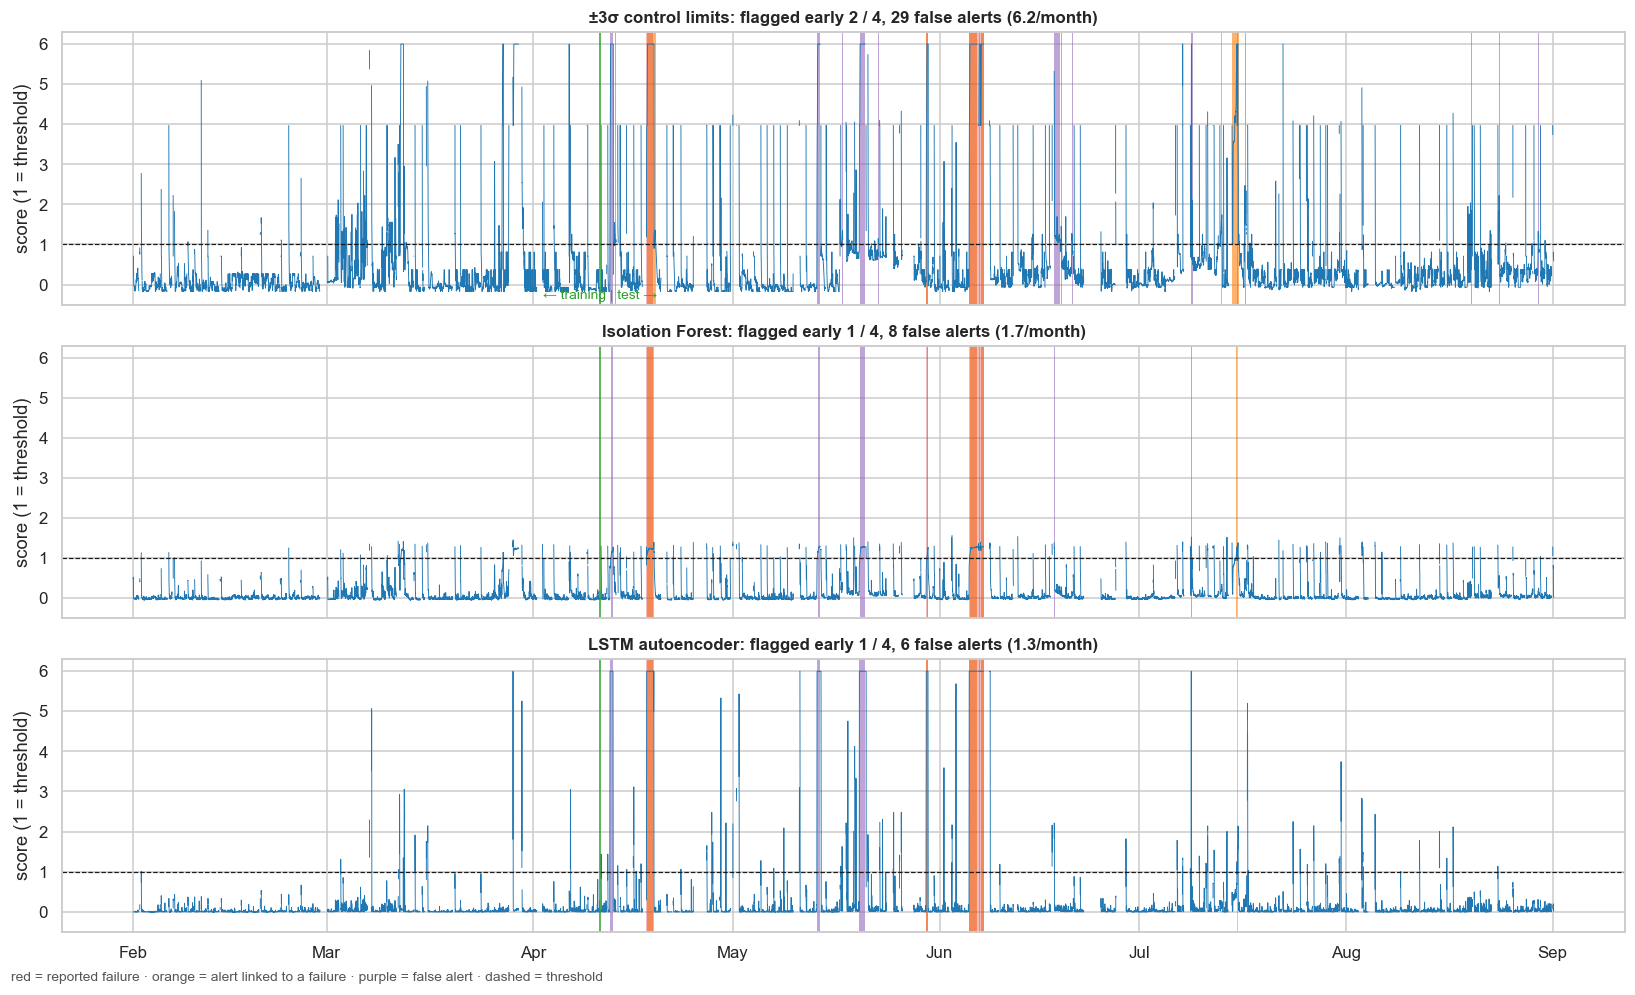

In [4]:
train_mask = training_mask(feats, params).to_numpy()
healthy_med = {n: float(np.median(results[n]["df_alerts"]["smoothed_score"].to_numpy()[train_mask])) for n in MODELS}

def norm(n, s):
    """0 = healthy median, 1 = alert threshold."""
    return (s - healthy_med[n]) / (dets[n].threshold - healthy_med[n])

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for ax, n in zip(axes, MODELS):
    r = results[n]["df_alerts"].set_index("timestamp")
    sm = norm(n, r["smoothed_score"].asfreq("1min"))
    ax.plot(sm.index, sm.clip(upper=6).values, lw=0.6, color="#1f77b4")
    ax.axhline(1, color="k", ls="--", lw=0.8)
    ax.set_ylim(-0.5, 6.3)
    ax.set_ylabel("score (1 = threshold)")
    for e in results[n]["alert_events"].itertuples():
        ax.axvspan(e.start, e.end + pd.Timedelta(minutes=30), color=ALERT_COLOR if e.failure_id else "#9467bd",
                   alpha=0.6, lw=0)
    for f in failures:
        ax.axvspan(f["start"], f["end"], color=FAIL_COLOR, alpha=0.3, lw=0)
    ax.axvline(pd.Timestamp(params["metropt"]["train_split"]["end"]), color="#2ca02c", lw=1)
    res = results[n]
    ax.set_title(f"{LABELS[n]}: flagged early {res['failures_flagged_str']}, "
                 f"{res['total_false_alerts']} false alerts ({res['false_alerts_per_month']:.1f}/month)")
axes[0].annotate("← training | test →", (pd.Timestamp(params["metropt"]["train_split"]["end"]), 0.02),
                 xycoords=("data", "axes fraction"), ha="center", color="#2ca02c", fontsize=9)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.text(0.01, 0.0, "red = reported failure · orange = alert linked to a failure · purple = false alert · "
         "dashed = threshold", fontsize=9, color="#555")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "metropt_alerts.png")
plt.show()

## 4. Zoom on each failure (Isolation Forest vs LSTM-AE)

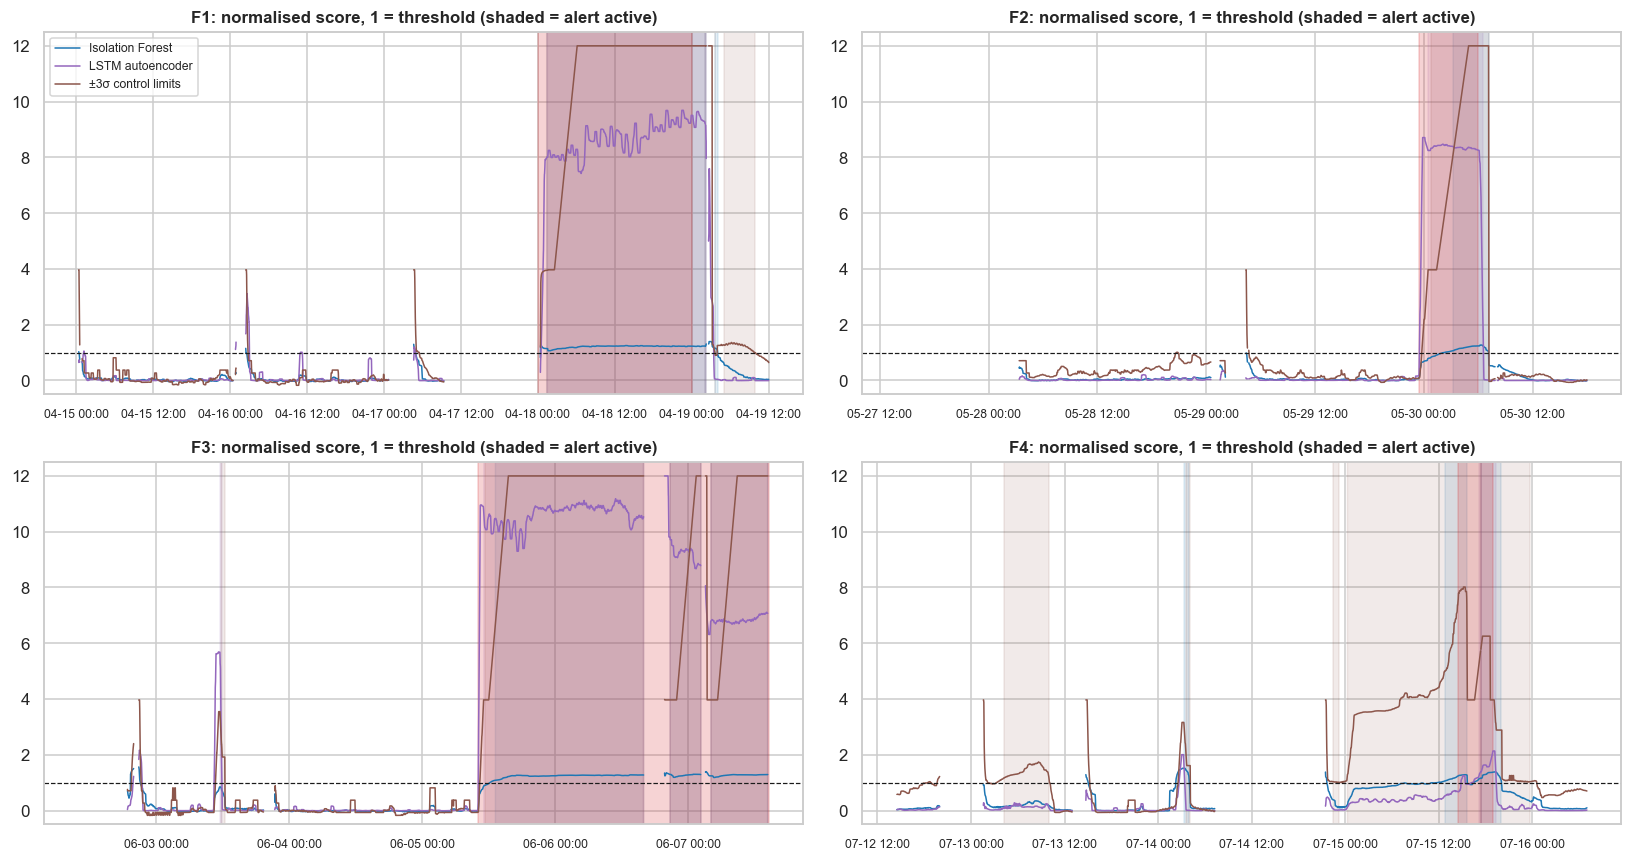

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, f in zip(axes.flat, failures):
    lo, hi = f["start"] - pd.Timedelta(hours=72), f["end"] + pd.Timedelta(hours=12)
    for n, c in [("isolation_forest", "#1f77b4"), ("lstm_autoencoder", "#9467bd"), ("control_limits", "#8c564b")]:
        r = results[n]["df_alerts"].set_index("timestamp").loc[lo:hi].asfreq("1min")
        ax.plot(r.index, norm(n, r["smoothed_score"]).clip(upper=12), color=c, lw=1, label=LABELS[n])
        on = r["alert_flag"].fillna(False).astype(bool)
        ax.fill_between(r.index, 0, 1, where=on, transform=ax.get_xaxis_transform(), color=c, alpha=0.12)
    ax.axhline(1, color="k", ls="--", lw=0.8)
    ax.axvspan(f["start"], f["end"], color=FAIL_COLOR, alpha=0.2)
    ax.set_ylim(-0.5, 12.5)
    ax.set_title(f"{f['id']}: normalised score, 1 = threshold (shaded = alert active)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M")); ax.tick_params(axis="x", labelsize=8)
axes[0, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## 5. What are the false alerts?

Each false alert is matched against the unreported full-load episodes from notebook 02.

In [6]:
x = feats.set_index("timestamp")
fe = results["isolation_forest"]["false_events"].copy()
fe["max_duty_60m"] = [x.loc[r.start:r.end, "duty_cycle_60m"].max() for r in fe.itertuples()]
fe["max_run_min"] = [x.loc[r.start:r.end, "max_load_run_min_60m"].max() for r in fe.itertuples()]
fe["max_idle_decay"] = [x.loc[r.start:r.end, "idle_decay_rate_60m"].max() for r in fe.itertuples()]
fe["looks_like_leak"] = fe["max_run_min"] > 60
print(f"Isolation Forest false alerts: {len(fe)}; {int(fe['looks_like_leak'].sum())} coincide with "
      "multi-hour continuous loading (possible unreported leaks)")
display(fe[["start", "end", "duration_hours", "shift", "max_duty_60m", "max_run_min", "max_idle_decay",
            "looks_like_leak"]].round(2))

Isolation Forest false alerts: 8; 3 coincide with multi-hour continuous loading (possible unreported leaks)


,start,end,duration_hours,shift,max_duty_60m,max_run_min,max_idle_decay,looks_like_leak
2,2020-04-12 17:18:00,2020-04-13 00:49:00,7.52,Shift 2 (14-22),1.00,705.48,0.24,True
5,2020-05-13 16:40:00,2020-05-14 00:56:00,8.27,Shift 2 (14-22),1.00,672.73,NaN,True
6,2020-05-20 01:41:00,2020-05-20 19:48:00,18.12,Shift 3 (22-06),1.00,1286.05,NaN,True
13,2020-06-18 05:56:00,2020-06-18 06:12:00,0.27,Shift 3 (22-06),0.35,10.40,0.22,False
14,2020-07-08 19:07:00,2020-07-08 19:50:00,0.72,Shift 2 (14-22),0.84,34.70,1.26,False
18,2020-07-17 05:35:00,2020-07-17 06:29:00,0.90,Shift 3 (22-06),0.98,44.47,0.26,False
19,2020-08-03 10:00:00,2020-08-03 10:25:00,0.42,Shift 1 (06-14),0.57,31.72,0.11,False
20,2020-08-05 09:22:00,2020-08-05 09:28:00,0.10,Shift 1 (06-14),0.28,12.57,0.12,False


## 6. Alerts by operating shift

False alerts per month of *scored time in that shift*, so each shift is normalised by its own exposure.

,±3σ control limits,Isolation Forest,LSTM autoencoder
Shift 1 (06-14),5.33,1.52,1.52
Shift 2 (14-22),9.96,2.49,1.66
Shift 3 (22-06),9.35,2.81,1.87


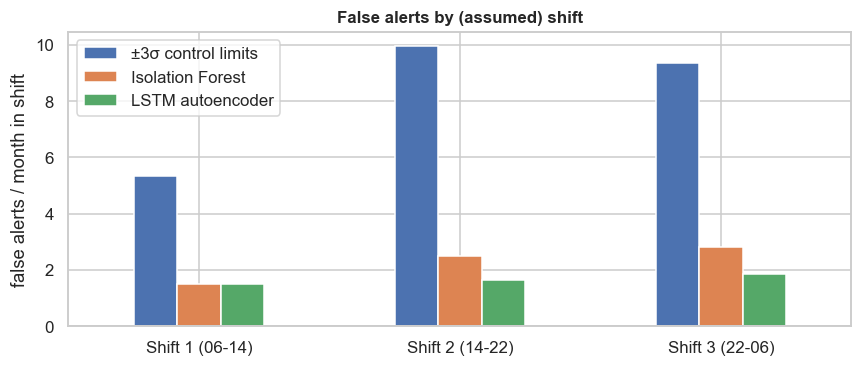

In [7]:
shift_tbl = pd.DataFrame({LABELS[n]: results[n]["false_alerts_per_month_by_shift"] for n in MODELS}).round(2)
display(shift_tbl)
fig, ax = plt.subplots(figsize=(8, 3.5))
shift_tbl.plot.bar(ax=ax, rot=0)
ax.set(ylabel="false alerts / month in shift", title="False alerts by (assumed) shift")
plt.tight_layout(); plt.show()

## 7. Sensitivity checks

**(a) Anticipation window.** How much of the "early" credit depends on the 72 h rule?

In [8]:
rows = []
for hrs in (12, 24, 48, 72):
    for n in MODELS:
        r = results[n]
        res = evaluate_backtest(r["df_alerts"], r["alert_events"].drop(columns="failure_id"), failures=failures,
                                anticipation_hours=hrs, grace_hours=params["metropt"]["backtest"]["post_failure_grace_hours"],
                                eval_start=pd.Timestamp(params["metropt"]["train_split"]["end"]))
        rows.append({"anticipation_h": hrs, "model": LABELS[n], "flagged_early": res["failures_flagged_str"],
                     "median_lead_h": round(res["median_lead_time_hours"], 1), "false_alerts": res["total_false_alerts"]})
display(pd.DataFrame(rows).pivot(index="model", columns="anticipation_h", values="flagged_early"))

anticipation_h,12,24,48,72
model,,,,
Isolation Forest,1 / 4,1 / 4,1 / 4,1 / 4
LSTM autoencoder,0 / 4,0 / 4,1 / 4,1 / 4
±3σ control limits,1 / 4,1 / 4,2 / 4,2 / 4


**(b) Persistence rule.** A shorter persistence period warns sooner but raises more nuisance alerts.

In [9]:
rows = []
for pers in (15, 30, 60, 120):
    p2 = {**params, "metropt": {**params["metropt"], "alert_logic": {**params["metropt"]["alert_logic"],
                                                                     "persistence_minutes": pers}}}
    for n in MODELS:
        res = backtest_scores(scores, f"score_{n}", dets[n].threshold, p2, failures=failures)
        rows.append({"persistence_min": pers, "model": LABELS[n], "flagged_early": res["failures_flagged_count"],
                     "detected": res["failures_detected_count"], "false_alerts_per_month": round(res["false_alerts_per_month"], 2),
                     "net_value_usd": round(res["net_economic_value"])})
display(pd.DataFrame(rows).set_index(["persistence_min", "model"]))

flagged_early  detected  false_alerts_per_month  net_value_usd
persistence_min model                                                                             
15              ±3σ control limits              3         4                   26.58          -4500
                Isolation Forest                3         4                   11.91          25000
                LSTM autoencoder                3         4                   11.91          25000
30              ±3σ control limits              3         4                   18.92           8500
                Isolation Forest                2         4                    5.53          24000
                LSTM autoencoder                3         4                    8.93          32000
60              ±3σ control limits              2         4                    6.17          17500
                Isolation Forest                1         4                    1.70          12000
                LSTM autoencoder                1         4                    1.28          13000
120             ±3σ control limits              1         4                    2.98           9000
                Isolation Forest                1         4                    0.64          14500
                LSTM autoencoder                0         4                    0.64          -1500

## 8. Takeaways

- **All three detectors catch all four leaks by the end of the reported window.** Most catch them within ~1–2 h of onset, when continuous loading and hot oil become unmistakable.
- **Early warning is limited by the data, not only the models.** F4 (idle-decay precursor) is the one genuinely predictable failure. F3's early flags come from brief full-load excursions two days ahead. F1 is hidden by a frozen logger.
- **The LSTM autoencoder gives the best precision** (fewest false alerts) at its default threshold. The control limits catch the most failures early but alert much more often.
- **Many "false" alerts look like real leaks** (hours of continuous loading) that were not in the maintenance report. The false-alarm rates are therefore pessimistic.
- **Shifts:** for the Isolation Forest and LSTM-AE, false alerts are spread fairly evenly across the three (assumed) shifts, at ~1.5–2.8 per month of shift time, with the night shift slightly highest. The control limits alert mostly in the afternoon and night shifts. There is no strong case for shift-specific thresholds.
- **Persistence is a real lever:** dropping it to 30 min lets the LSTM-AE flag 3 of 4 failures early, at the cost of ~9 false alerts/month (see 7b).
- Default thresholds are not the economically optimal ones. Notebook 06 sweeps them against the cost model.